# Шаг 19. Построение визуализации

✅ Все данные успешно загружены.

=== 1. ABC-анализ производителей (Вопрос 1) ===


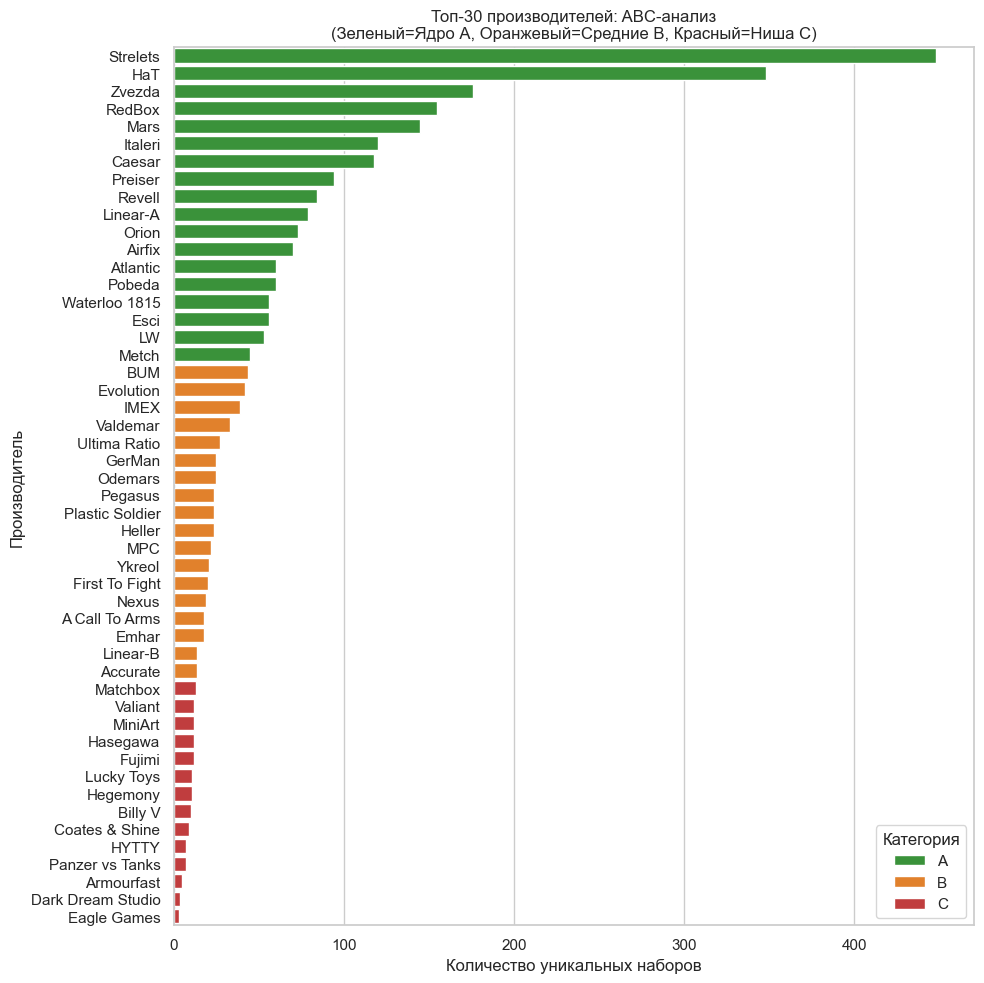


=== 2. Динамика рынка: количество наборов и качество (Вопросы 4, 8) ===


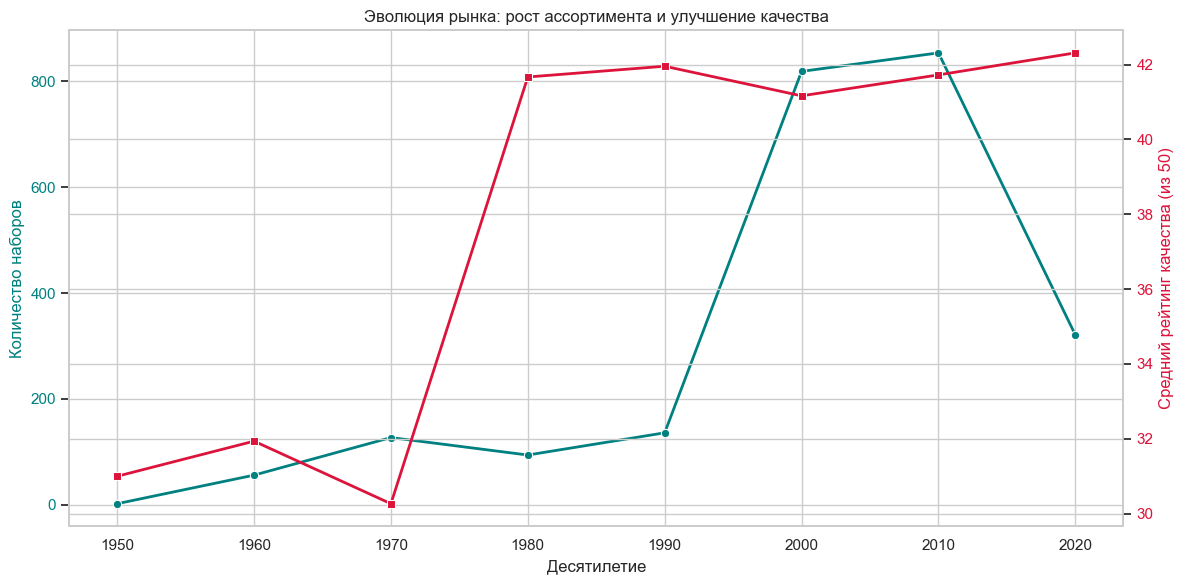


=== 3. Связь размера набора и его качества (Вопрос 10) ===


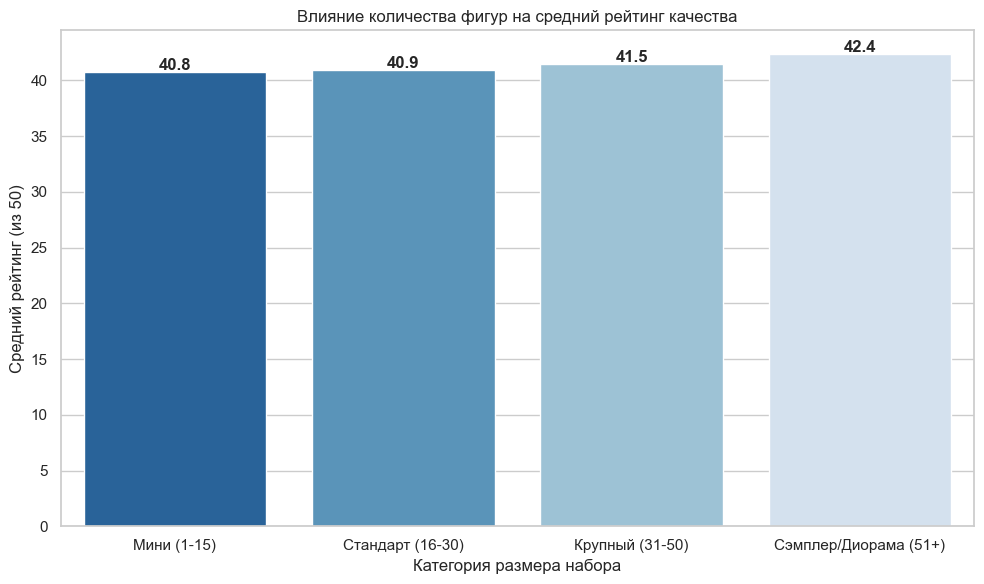


=== 4. Тепловая карта покрытия: Фокус на 1939–1945 гг. (Вопросы 2, 3, 6) ===


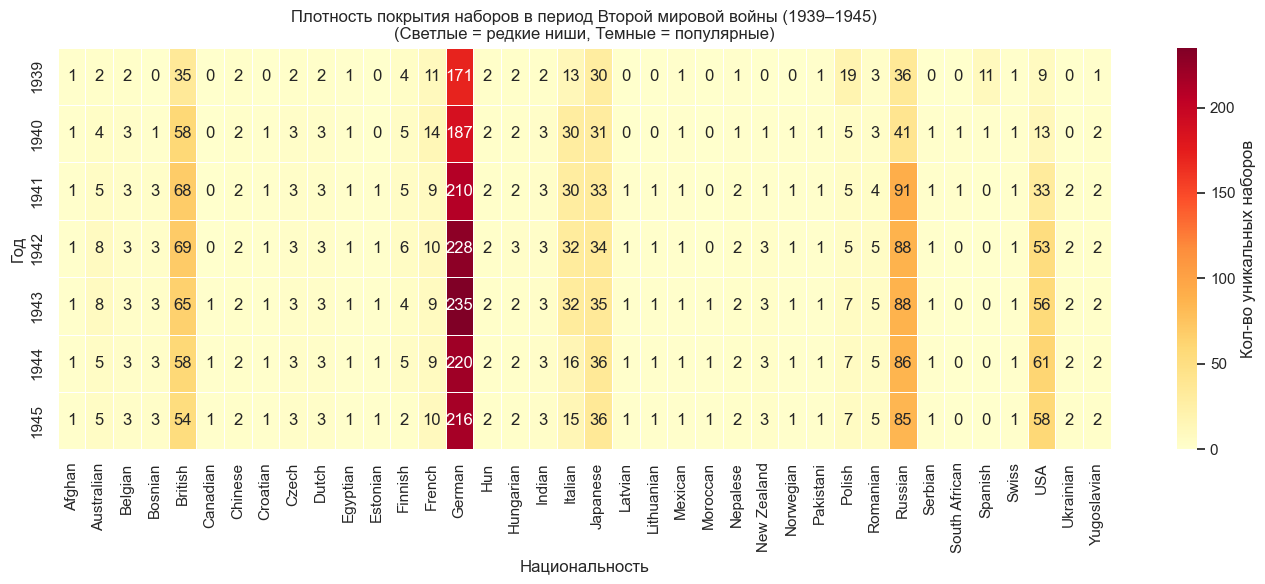


=== 5. RFM-анализ активности производителей по темам (Вопрос 13) ===


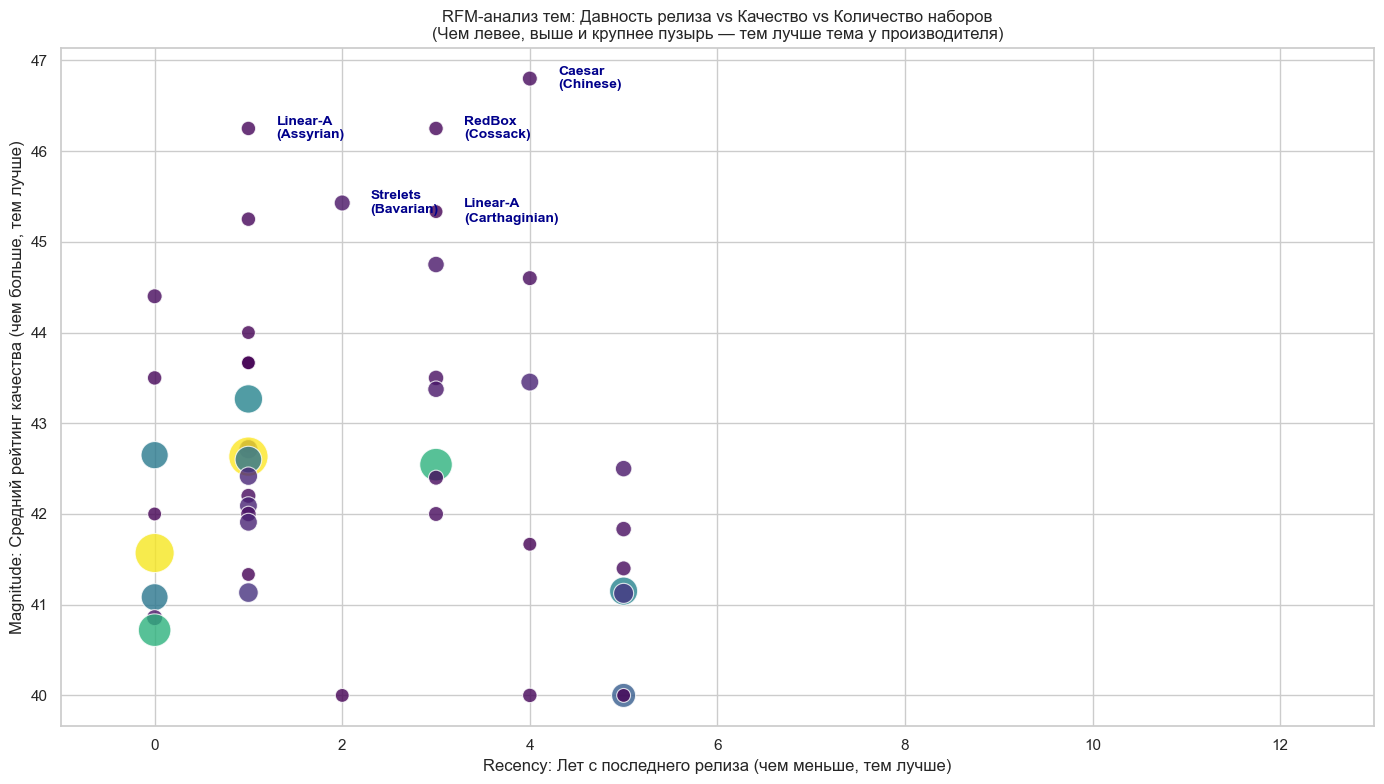

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ==============================================================================
# 1. НАСТРОЙКА ВИЗУАЛИЗАЦИИ И ШРИФТОВ
# ==============================================================================
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Microsoft YaHei'] 
plt.rcParams['axes.unicode_minus'] = False

# ==============================================================================
# 2. ЗАГРУЗКА ОСНОВНЫХ ДАННЫХ
# ==============================================================================
df_sets = pd.read_csv('df_sets.csv', dtype={
    'release_year': 'Int64', 'aggregate_rating': 'Int64', 'num_figures': 'Int64',
    'decade': 'Int64', 'years_since_release': 'Int64'
})

df_long = pd.read_csv('df_consolidated_clean.csv', dtype={
    'release_year': 'Int64', 'aggregate_rating': 'Int64', 'num_figures': 'Int64',
    'decade': 'Int64', 'years_since_release': 'Int64'
})

# ==============================================================================
# 3. ПОДГОТОВКА ДАННЫХ ДЛЯ ТЕПЛОВОЙ КАРТЫ (Генерация, если файла нет)
# ==============================================================================
heatmap_file = 'heatmap_year_nationality_coverage.csv'

if not os.path.exists(heatmap_file):
    print("⚙️ Генерация матрицы для тепловой карты (Годы × Национальности)...")
    df_work = df_long[df_long['nationality'] != 'Не указано'].copy()
    df_work['year_list'] = df_work.apply(
        lambda row: list(range(int(row['years_from']), int(row['years_to']) + 1)), axis=1
    )
    df_expanded_viz = df_work.explode('year_list').rename(columns={'year_list': 'year'})
    
    heatmap_data = df_expanded_viz.groupby(['year', 'nationality']).agg(
        kit_count=('id', 'nunique')
    ).reset_index()
    
    pivot_coverage = heatmap_data.pivot_table(
        index='year', columns='nationality', values='kit_count', fill_value=0
    )
    pivot_coverage.to_csv(heatmap_file, encoding='utf-8')
    print("✅ Файл heatmap_year_nationality_coverage.csv создан.\n")

df_heatmap = pd.read_csv(heatmap_file, index_col='year')

# Загрузка агрегированных таблиц
df_abc = pd.read_csv('agg_manufacturers_abc.csv')
df_decades = pd.read_csv('agg_decades_dynamics.csv')
df_rfm = pd.read_csv('agg_rfm_actual_hits.csv')
df_figures = pd.read_csv('agg_figure_categories.csv')

print("✅ Все данные успешно загружены.")


# ==============================================================================
# 4. ВИЗУАЛИЗАЦИИ
# ==============================================================================

print("\n=== 1. ABC-анализ производителей (Вопрос 1) ===")
plt.figure(figsize=(10, 10)) # Увеличиваем высоту, так как производителей будет больше
palette_abc = {'A': '#2ca02c', 'B': '#ff7f0e', 'C': '#d62728'}

# Берем Топ-30, чтобы захватить переход в категории B и C
df_abc_top30 = df_abc.head(50)

sns.barplot(
    data=df_abc_top30, 
    x='kit_count', y='manufacturer', 
    hue='ABC_Category', palette=palette_abc, legend=True # Включаем легенду
)
plt.title('Топ-30 производителей: ABC-анализ\n(Зеленый=Ядро А, Оранжевый=Средние B, Красный=Ниша C)')
plt.xlabel('Количество уникальных наборов')
plt.ylabel('Производитель')
plt.legend(title='Категория', loc='lower right')
plt.tight_layout()
plt.show()


print("\n=== 2. Динамика рынка: количество наборов и качество (Вопросы 4, 8) ===")
fig, ax1 = plt.subplots(figsize=(12, 6))
color1 = 'teal'
ax1.set_xlabel('Десятилетие')
ax1.set_ylabel('Количество наборов', color=color1)
sns.lineplot(data=df_decades, x='decade', y='kit_count', marker='o', color=color1, ax=ax1, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
color2 = 'crimson'
ax2.set_ylabel('Средний рейтинг качества (из 50)', color=color2)
sns.lineplot(data=df_decades, x='decade', y='avg_rating', marker='s', color=color2, ax=ax2, linewidth=2)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Эволюция рынка: рост ассортимента и улучшение качества')
plt.xticks(df_decades['decade'].dropna().astype(int))
plt.tight_layout()
plt.show()


print("\n=== 3. Связь размера набора и его качества (Вопрос 10) ===")
plt.figure(figsize=(10, 6))
order = ['Мини (1-15)', 'Стандарт (16-30)', 'Крупный (31-50)', 'Сэмплер/Диорама (51+)']
sns.barplot(
    data=df_figures, x='figure_category', y='avg_rating', 
    order=order, palette="Blues_r", hue='figure_category', legend=False
)
plt.title('Влияние количества фигур на средний рейтинг качества')
plt.xlabel('Категория размера набора')
plt.ylabel('Средний рейтинг (из 50)')
for i, v in enumerate(df_figures.set_index('figure_category').loc[order, 'avg_rating']):
    plt.text(i, v + 0.2, f"{v:.1f}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


print("\n=== 4. Тепловая карта покрытия: Фокус на 1939–1945 гг. (Вопросы 2, 3, 6) ===")
# ИСПРАВЛЕНО: Берем узкий, всем понятный период высокой плотности данных
df_slice = df_heatmap.loc[1939:1945].copy()

# Удаляем национальности (столбцы), у которых в этом периоде 0 наборов, чтобы график был плотным
df_slice_filtered = df_slice.loc[:, (df_slice != 0).any(axis=0)]

plt.figure(figsize=(14, 6))
sns.heatmap(
    df_slice_filtered, 
    cmap="YlOrRd", 
    annot=True,          # Показываем числа прямо в ячейках для наглядности
    fmt="g",             # Формат чисел без лишних нулей
    cbar_kws={'label': 'Кол-во уникальных наборов'},
    linewidths=0.5
)
plt.title('Плотность покрытия наборов в период Второй мировой войны (1939–1945)\n(Светлые = редкие ниши, Темные = популярные)')
plt.xlabel('Национальность')
plt.ylabel('Год')
plt.tight_layout()
plt.show()


print("\n=== 5. RFM-анализ активности производителей по темам (Вопрос 13) ===")
# Пузырьковая диаграмма идеально показывает 3 метрики RFM одновременно
# Оставляем только значимые темы (где выпущено >= 3 наборов), чтобы не засорять график
df_rfm_plot = df_rfm[df_rfm['Frequency'] >= 3].copy()

plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=df_rfm_plot,
    x='Recency',
    y='Magnitude',
    size='Frequency',
    sizes=(100, 800),        # Минимальный и максимальный размер пузыря
    hue='Frequency',         # Цвет также зависит от частоты для усиления эффекта
    palette='viridis',
    alpha=0.8,
    legend=False             # Отключаем стандартную легенду размеров для чистоты
)

# Добавляем текстовые подписи для ТОП-5 лучших комбинаций (высокий рейтинг + свежий релиз)
top_5_rfm = df_rfm_plot.sort_values(by=['Magnitude', 'Recency'], ascending=[False, True]).head(5)
for idx, row in top_5_rfm.iterrows():
    plt.text(
        row['Recency'] + 0.3, row['Magnitude'], 
        f"{row['manufacturer']}\n({row['nationality']})",
        fontsize=10, fontweight='bold', color='darkblue',
        verticalalignment='center'
    )

plt.title('RFM-анализ тем: Давность релиза vs Качество vs Количество наборов\n(Чем левее, выше и крупнее пузырь — тем лучше тема у производителя)')
plt.xlabel('Recency: Лет с последнего релиза (чем меньше, тем лучше)')
plt.ylabel('Magnitude: Средний рейтинг качества (чем больше, тем лучше)')
plt.xlim(left=-1, right=df_rfm_plot['Recency'].max() + 8) # Место для подписей справа
plt.tight_layout()
plt.show()

## Промежуточные выводы из графиков (интерпретация):
**ABC-анализ**: Визуально подтверждает, что рынок поляризован. Категория A (зеленые столбцы) — это 7-8 ключевых игроков, на которых стоит ориентироваться в первую очередь. Категория C (красные) — это длинный хвост нишевых брендов.

**Динамика (двойная ось)**: Наглядно показывает "ножницы": в 1960-70-х годах наборов было мало, и их качество было низким (рейтинг 30). Начиная с 2000-х, количество наборов взлетело, а средний рейтинг стабилизировался на высоком уровне (41-42), что говорит о взрослении индустрии и появлении CAD-моделирования.

**Размер и качество**: Восходящий тренд. Наборы категории "Сэмплер/Диорама (51+)" имеют более высокий средний рейтинг (42.4), чем "Мини" (40.7).

**Тепловая карта**: (для наглядности взят срез данных на период Второй мировой войны). Это самый важный график для коллекционера.
Тёмные пятна показывают темы наборов с большим выбором. Светлые ячейки — непроработанные ниши.

**Актуальные хиты (RFM)**: Пузырьковая диаграмма позволяет оценить кто из производителей давно не выпускал наборы (ушли вправо), кто делает их качественно (поднялись вверх), и кто делает это массово (крупные пузыри). Подписаны топ-5.

## Результат шага
Построены 5 целевых визуализаций, каждая из которых закрывает конкретный аналитический вопрос.
Тепловая карта подготовлена как для просмотра в ноутбуке (срез 1939–1945), так и в полном объёме (файл heatmap_year_nationality_coverage.csv) для загрузки в BI-систему.